In [1]:
import uproot
import pandas as pd
import awkward as ak
import joblib
import os
import matplotlib.pyplot as plt  
import mplhep as hep  
import numpy as np
import zfit
from zfit import z
from zfit.loss import ExtendedUnbinnedNLL
from zfit.minimizers.minimizer_minuit import Minuit
import json
import warnings

/home/tandrade/.local/lib/python3.9/site-packages/zfit/__init__.py:63: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
signal_path = "/home/tandrade/Flavour_Anomalies/Data/Data_final_merged.root" 
tree_name   = "tree_ML"

In [3]:
model = joblib.load("final_bdt_model.joblib")

In [4]:
features = [
    'BToTrkTrkMuMu_l_xy_good',
    'BToTrkTrkMuMu_l_xy_unc_good',
    
    'BToTrkTrkMuMu_dca_good',
    'BToTrkTrkMuMu_dcaErr_good',

    'BToTrkTrkMuMu_trk1_dca_good',
    'BToTrkTrkMuMu_trk1_dcaErr_good',
    
    'BToTrkTrkMuMu_trk2_dca_good',
    'BToTrkTrkMuMu_trk2_dcaErr_good',
    
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi_good',
    'BToTrkTrkMuMu_fit_pt_good',
    'BToTrkTrkMuMu_fit_cos2D_good',
    'BToTrkTrkMuMu_svprob_good'
]

cut_features = [
    'MuMu_mass_good', 
    'BToTrkTrkMuMu_fit_mass_Kpi_good',
    'HLT_DoubleMu4_3_LowMass'
]

In [5]:
signal_file = uproot.open(signal_path)[tree_name]

In [6]:
cols_to_load = features + cut_features
signal_ak = signal_file.arrays(cols_to_load, library="ak")

In [7]:
signal_df = ak.to_dataframe(signal_ak)

In [8]:
sig_pairs = [
    ('BToTrkTrkMuMu_l_xy_good', 'BToTrkTrkMuMu_l_xy_unc_good', 'BToTrkTrkMuMu_l_xy_sig_good'),
    ('BToTrkTrkMuMu_dca_good', 'BToTrkTrkMuMu_dcaErr_good', 'BToTrkTrkMuMu_dca_sig_good'),
    ('BToTrkTrkMuMu_trk1_dca_good', 'BToTrkTrkMuMu_trk1_dcaErr_good', 'BToTrkTrkMuMu_trk1_dca_sig_good'),
    ('BToTrkTrkMuMu_trk2_dca_good', 'BToTrkTrkMuMu_trk2_dcaErr_good', 'BToTrkTrkMuMu_trk2_dca_sig_good')
]

for val, err, sig in sig_pairs:
    signal_df[sig] = signal_df[val] / signal_df[err]

In [9]:
signal_df.replace([np.inf, -np.inf], np.nan, inplace=True)
signal_df = signal_df.dropna()

In [10]:
df = pd.concat([signal_df], ignore_index=True)

cut_mass_B = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] < 5.6)
cut_mass_MuMu = ( ((df['MuMu_mass_good'] > 1.0) & (df['MuMu_mass_good'] < 2.9)) | ((df['MuMu_mass_good'] > 4.0) & (df['MuMu_mass_good'] < 4.8)) )
cut_trigger = df['HLT_DoubleMu4_3_LowMass'] == 1

final_selection_mask = cut_mass_B & cut_mass_MuMu & cut_trigger
df_cut = df[final_selection_mask]

In [11]:
probabilities = model.predict_proba(df_cut[features])[:, 1]
predictions = model.predict(df_cut[features])

In [12]:
df_cut['bdt_score'] = probabilities
df_cut['bdt_prediction'] = predictions

/tmp/ipykernel_16491/291922684.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cut['bdt_score'] = probabilities
/tmp/ipykernel_16491/291922684.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cut['bdt_prediction'] = predictions


In [15]:
bdt_cut = 0.93  # Mesmo valor que você usou
df_signal_like = df_cut[df_cut['bdt_score'] > bdt_cut]

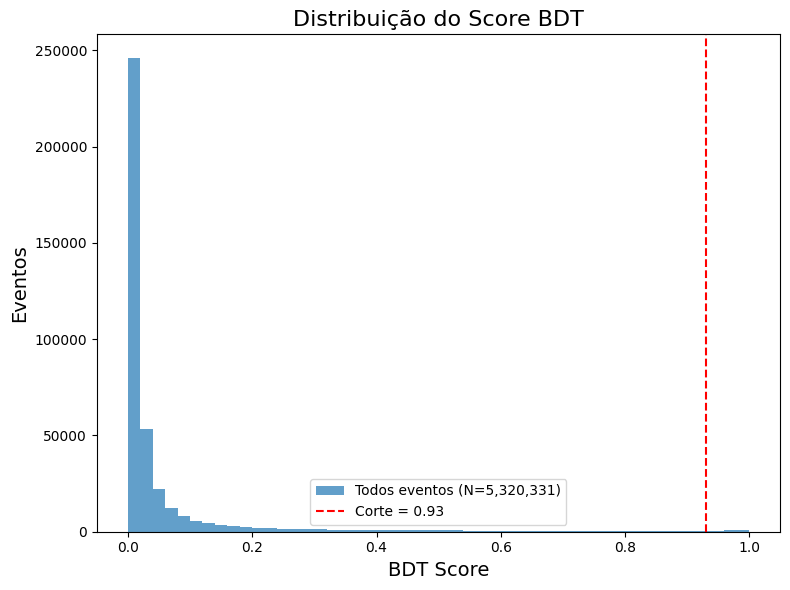

In [16]:
plt.figure(figsize=(8, 6))
plt.hist(df_cut['bdt_score'], bins=50, alpha=0.7, 
         label=f'Todos eventos (N={len(signal_df):,})')
plt.axvline(x=bdt_cut, color='red', linestyle='--', 
           label=f'Corte = {bdt_cut}')
plt.xlabel('BDT Score', fontsize=14)
plt.ylabel('Eventos', fontsize=14)
plt.title('Distribuição do Score BDT', fontsize=16)
plt.legend()
#plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

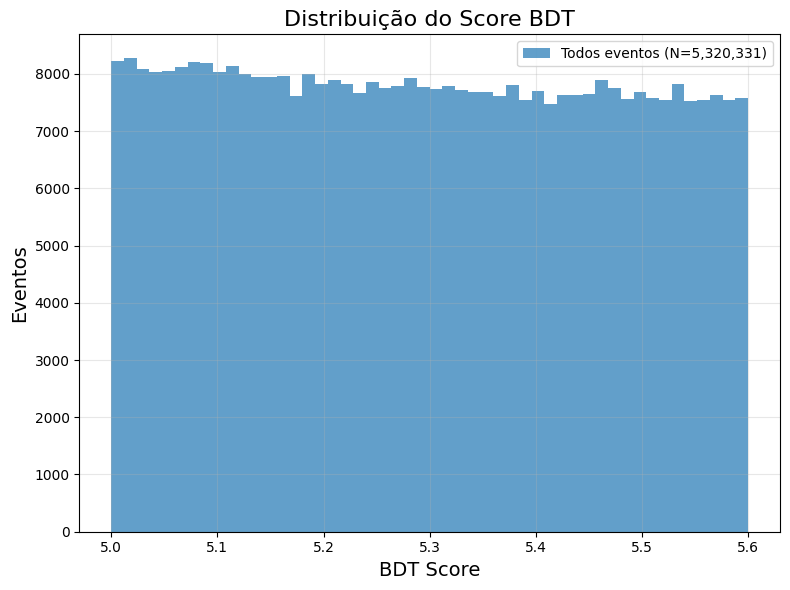

In [17]:
plt.figure(figsize=(8, 6))
plt.hist(df_cut['BToTrkTrkMuMu_fit_mass_Kpi_good'], bins=50, range = (5, 5.6), alpha=0.7, label=f'Todos eventos (N={len(signal_df):,})')
plt.xlabel('BDT Score', fontsize=14)
plt.ylabel('Eventos', fontsize=14)
plt.title('Distribuição do Score BDT', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

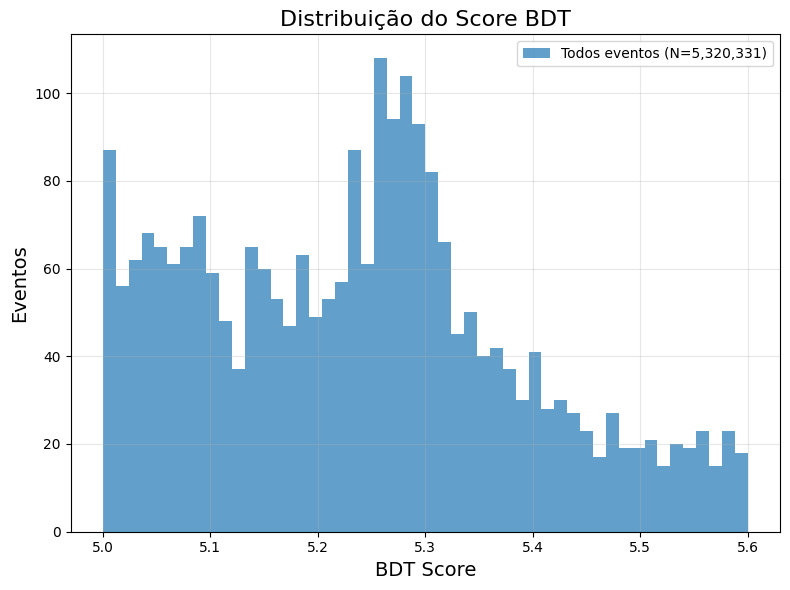

In [18]:
plt.figure(figsize=(8, 6))
plt.hist(df_signal_like['BToTrkTrkMuMu_fit_mass_Kpi_good'], bins=50, range = (5, 5.6), alpha=0.7, label=f'Todos eventos (N={len(signal_df):,})')
plt.xlabel('BDT Score', fontsize=14)
plt.ylabel('Eventos', fontsize=14)
plt.title('Distribuição do Score BDT', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [19]:
import zfit
import numpy as np
from zfit import z  # Opcional, para facilitar acesso

# --- 1. PREPARAÇÃO DOS DADOS (Corrigida) ---

# Supondo que a coluna de massa no DataFrame se chama 'B0_mass'
coluna_massa = 'BToTrkTrkMuMu_fit_mass_Kpi_good' 
mass_min = 5.0
mass_max = 5.6

# Aplicar corte do BDT
df_bdt_cut = df_signal_like[df_signal_like['bdt_score'] > bdt_cut]

# Filtrar eventos na janela de sinal (Usando a coluna específica!)
mask = (df_bdt_cut[coluna_massa] >= mass_min) & (df_bdt_cut[coluna_massa] <= mass_max)
df_final = df_bdt_cut[mask]

# *** A CORREÇÃO ESTÁ AQUI ***
# Extrair apenas a coluna de massa como array numpy
data_array = df_final[coluna_massa].to_numpy()

print(f"Eventos para o fit: {len(data_array)}")


# --- 2. CONFIGURAÇÃO DO ZFIT ---

obs = zfit.Space(coluna_massa, limits=(mass_min, mass_max))

# Parâmetros
mu = zfit.Parameter("mu", 5.279, mass_min, mass_max)
sigma = zfit.Parameter("sigma", 0.025, 0.005, 0.1)
tau = zfit.Parameter("tau", -2.0, -10.0, 0.0)

# Yields (Extended Fit)
n_total = len(data_array)
nsig = zfit.Parameter("nsig", int(n_total * 0.4), 0, n_total * 2)
nbkg = zfit.Parameter("nbkg", int(n_total * 0.6), 0, n_total * 2)

# PDFs
signal_pdf = zfit.pdf.Gauss(mu=mu, sigma=sigma, obs=obs, extended=nsig)
bkg_pdf = zfit.pdf.Exponential(lambda_=tau, obs=obs, extended=nbkg)
total_pdf = zfit.pdf.SumPDF([signal_pdf, bkg_pdf])

# --- 3. CRIAÇÃO DO DATA E FIT (Corrigido) ---

# Agora passamos o 'data_array' que é puramente numpy
data_z = zfit.Data.from_numpy(obs=obs, array=data_array)

# Loss function
loss = zfit.loss.ExtendedUnbinnedNLL(model=total_pdf, data=data_z)

# Minimização
print(f"Executando minimização...")
minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(loss)

print(result)

Eventos para o fit: 2451
Executando minimização...
FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_1, Composed_autoparam_2]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi_good',) shape=(2451, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00011 │         -1534.82 |  9795.646 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name      value  (rounded)    at limit
------  ------------------  ----------
nsig               458.673       False
nbkg               1992.92       False
mu                 5.27757       False
sigma            0.0358438       False
tau 

Fit convergiu! Calculando erros (Hesse)...


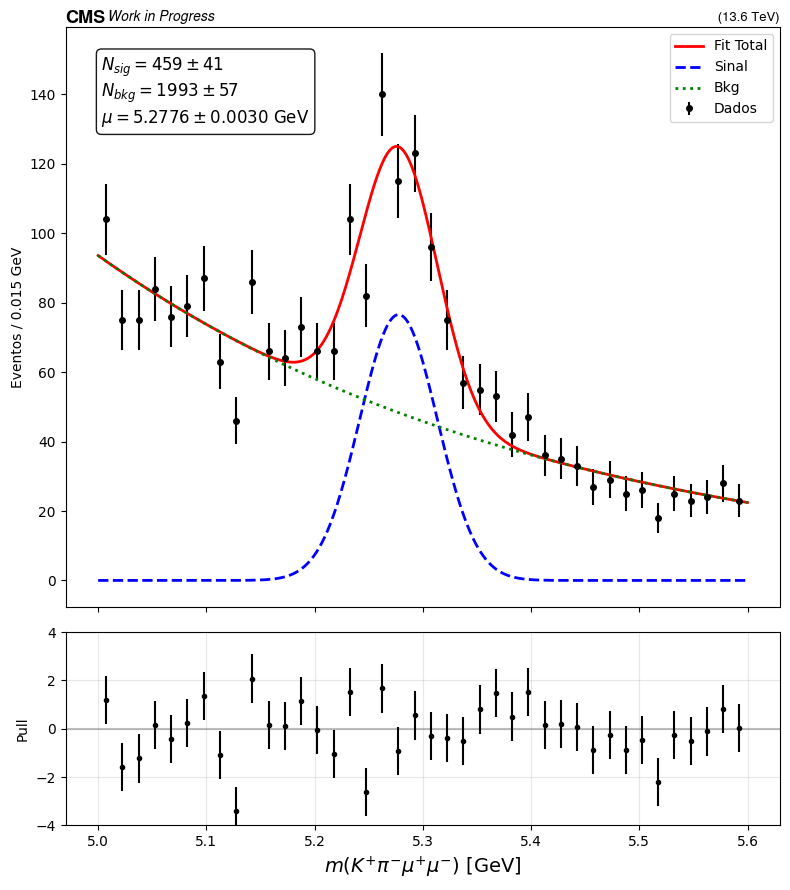

In [20]:
# 1. CALCULE OS ERROS ANTES DO PLOT
if result.valid:
    print("Fit convergiu! Calculando erros (Hesse)...")
    try:
        result.hesse() # <--- ESSA LINHA É OBRIGATÓRIA PARA TER O ['hesse']
    except Exception as e:
        print(f"Erro no Hesse: {e}")

# 2. CÓDIGO DO PLOT
fig, (ax_main, ax_res) = plt.subplots(2, 1, figsize=(8, 9), 
                           gridspec_kw={'height_ratios': [3, 1]},
                           sharex=True)

# Dados
bins_fit = 40
data_array = data_array if isinstance(data_array, np.ndarray) else data_array.to_numpy()
if len(data_array.shape) > 1: data_array = data_array.flatten()

counts, edges = np.histogram(data_array, bins=bins_fit, range=(mass_min, mass_max))
centers = 0.5 * (edges[:-1] + edges[1:])
width = edges[1] - edges[0]
yerr = np.sqrt(counts)
yerr[yerr == 0] = 1 

# Plot Principal
ax_main.errorbar(centers, counts, yerr=yerr, fmt='o', color='black', markersize=4, label='Dados')

# Fit Curves
x_fit = np.linspace(mass_min, mass_max, 500)
scale = width
pdf_total = total_pdf.pdf(x_fit).numpy() * (nsig.value() + nbkg.value()) * scale
pdf_sig = signal_pdf.pdf(x_fit).numpy() * nsig.value() * scale
pdf_bkg = bkg_pdf.pdf(x_fit).numpy() * nbkg.value() * scale

ax_main.plot(x_fit, pdf_total, 'r-', lw=2, label='Fit Total')
ax_main.plot(x_fit, pdf_sig, 'b--', lw=2, label='Sinal')
ax_main.plot(x_fit, pdf_bkg, 'g:', lw=2, label='Bkg')

# Texto dos Resultados (Com proteção contra erro se o hesse falhar)
try:
    n_s_err = result.params[nsig]['hesse']['error']
    n_b_err = result.params[nbkg]['hesse']['error']
    mu_err  = result.params[mu]['hesse']['error']
except:
    n_s_err = n_b_err = mu_err = 0

fit_text = (
    rf"$N_{{sig}} = {nsig.value():.0f} \pm {n_s_err:.0f}$" + "\n" +
    rf"$N_{{bkg}} = {nbkg.value():.0f} \pm {n_b_err:.0f}$" + "\n" +
    rf"$\mu = {mu.value():.4f} \pm {mu_err:.4f}$ GeV"
)

ax_main.text(0.05, 0.95, fit_text, transform=ax_main.transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Resíduos
expected = total_pdf.pdf(centers).numpy() * (nsig.value() + nbkg.value()) * width
resid = (counts - expected) / yerr

ax_res.axhline(0, color='gray', alpha=0.5)
ax_res.errorbar(centers, resid, yerr=1, fmt='o', color='black', markersize=3)
ax_res.set_ylabel("Pull")
ax_res.set_ylim(-4, 4)
ax_res.grid(True, alpha=0.3)
ax_res.set_xlabel(r"$m(K^{+}\pi^{-}\mu^{+}\mu^{-})$ [GeV]", fontsize=14)

# Legendas e Estilo
ax_main.set_ylabel(f"Eventos / {width:.3f} GeV")
ax_main.legend(loc='upper right')
hep.cms.label("Work in Progress", data=True, com=13.6, ax=ax_main)

plt.tight_layout()
plt.show()

/tmp/ipykernel_16491/859183682.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


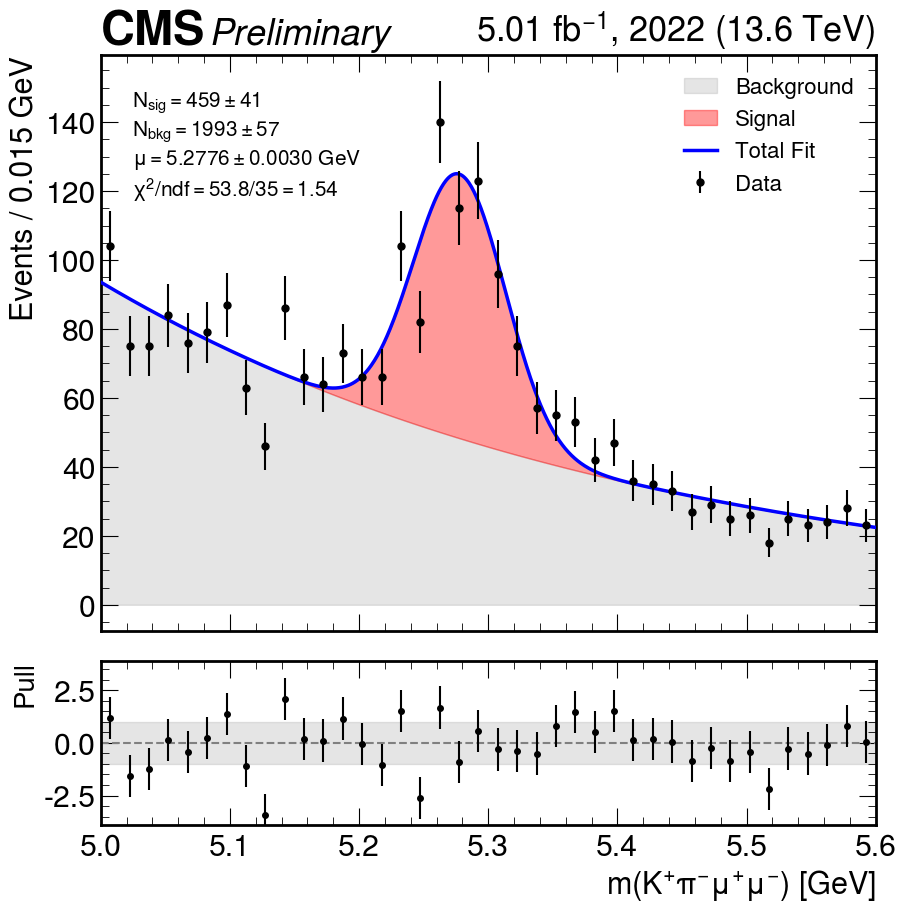

In [21]:
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np

# Ativa o estilo CMS
hep.style.use("CMS")

# ... (Seu código de fit anterior, assumindo que as variáveis pdfs e dados já existem) ...

# --- 1. CÁLCULO DO CHI2/NDF ---
bins_fit = 40
# Garante que é array numpy e flat
data_array = data_array if isinstance(data_array, np.ndarray) else data_array.to_numpy()
if len(data_array.shape) > 1: data_array = data_array.flatten()

counts, edges = np.histogram(data_array, bins=bins_fit, range=(mass_min, mass_max))
centers = 0.5 * (edges[:-1] + edges[1:])
width = edges[1] - edges[0]
yerr = np.sqrt(counts)
yerr[yerr == 0] = 1 

# Expectativa do modelo nos bins
expected = total_pdf.pdf(centers).numpy() * (nsig.value() + nbkg.value()) * width

# Cálculo do Chi2
residuals_array = (counts - expected) / yerr
chi2_val = np.sum(residuals_array**2)

# Graus de Liberdade (NDF)
n_params = len(result.params) 
ndf_val = len(counts) - n_params
chi2_ndf = chi2_val / ndf_val

# --- 2. PLOT ---
fig, (ax_main, ax_res) = plt.subplots(
    2, 1, 
    figsize=(10, 10), 
    gridspec_kw={'height_ratios': [3.5, 1], 'hspace': 0.08}, 
    sharex=True
)

# --- PLOT PRINCIPAL ---
# Dados
ax_main.errorbar(
    centers, counts, yerr=yerr, 
    fmt='ok', markersize=5, elinewidth=1.5, capsize=0, 
    label='Data', zorder=10
)

# Curvas para preenchimento
x_fit = np.linspace(mass_min, mass_max, 1000)
scale = width
pdf_bkg = bkg_pdf.pdf(x_fit).numpy() * nbkg.value() * scale
pdf_sig = signal_pdf.pdf(x_fit).numpy() * nsig.value() * scale
pdf_total = total_pdf.pdf(x_fit).numpy() * (nsig.value() + nbkg.value()) * scale

# --- ÁREAS SOMBREADAS ---

# Background: Opacidade AUMENTADA AQUI
ax_main.fill_between(
    x_fit, 0, pdf_bkg, 
    color='grey', 
    alpha=0.2,     # <--- MUDANÇA: De 0.5 para 0.8 (quase sólido)
    label='Background',
    zorder=1
)

# Sinal empilhado (mantive 0.4 para ver o grid/overlap se necessário, mas pode aumentar também)
ax_main.fill_between(
    x_fit, pdf_bkg, pdf_bkg + pdf_sig, 
    color='red', 
    alpha=0.4, 
    label='Signal',
    zorder=2
)

# Linha de contorno do Fit Total
ax_main.plot(x_fit, pdf_total, color='blue', lw=2.5, label='Total Fit', zorder=9)

# --- TEXTO COM CHI2 ---
try:
    n_s_err = result.params[nsig]['hesse']['error']
    n_b_err = result.params[nbkg]['hesse']['error']
    mu_err  = result.params[mu]['hesse']['error']
except:
    n_s_err = n_b_err = mu_err = 0

fit_text = (
    #r"$\bf{Fit\ Parameters}$" + "\n" +
    rf"$N_{{sig}} = {nsig.value():.0f} \pm {n_s_err:.0f}$" + "\n" +
    rf"$N_{{bkg}} = {nbkg.value():.0f} \pm {n_b_err:.0f}$" + "\n" +
    rf"$\mu = {mu.value():.4f} \pm {mu_err:.4f}$ GeV" + "\n" +
    #r"-----------------" + "\n" +
    rf"$\chi^2/ndf = {chi2_val:.1f}/{ndf_val} = {chi2_ndf:.2f}$"
)

ax_main.text(
    0.04, 0.94, fit_text, 
    transform=ax_main.transAxes, 
    fontsize=15, 
    verticalalignment='top',
    bbox=dict(boxstyle='square,pad=0.4', fc='white', alpha=0.85, ec='none')
)

# --- RESÍDUOS ---
ax_res.axhspan(-1, 1, color='gray', alpha=0.2)
ax_res.axhline(0, color='gray', ls='--')
ax_res.errorbar(centers, residuals_array, yerr=1, fmt='ok', markersize=4, elinewidth=1.5, capsize=0)

# Eixos e Legendas
ax_main.set_ylabel(f"Events / {width:.3f} GeV", fontsize=22)
ax_main.set_xlim(mass_min, mass_max)
ax_main.legend(loc='upper right', frameon=False, fontsize=16)
plt.setp(ax_main.get_xticklabels(), visible=False)

ax_res.set_ylabel(r"Pull", fontsize=20)
ax_res.set_ylim(-3.9, 3.9)
ax_res.set_xlabel(r"$m(K^{+}\pi^{-}\mu^{+}\mu^{-})$ [GeV]", fontsize=22)

hep.cms.label("Preliminary", data=True, com = 13.6, lumi=5.01, year=2022, ax=ax_main)

plt.tight_layout()
plt.subplots_adjust(hspace=0.06)
plt.savefig("Plots/Fit_Result_Chi2.png", dpi=300)
plt.show()